<a href="https://colab.research.google.com/github/Sakshee5/XAI-Assignments/blob/xai-in-llms/XAI_IN_LLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 8

#### Visualize the embedding space of an embedding model on the MTEB leaderboard using tSNE, PCA, and UMAP. Compare/contrast the approaches.

<br>
<br>

## Dataset Chosen to visualize
**Dataset Name**: GoEmotions

**Description**: The GoEmotions dataset consists of 58,000 Reddit comments annotated with 27 different emotion categorie.

**Reason for Choosing**: By visualizing the embeddings derived from different models, I can analyze how well these models differentiate between various emotions and identify potential clusters that represent semantic similarities.Moreover, easy to validate and visualize wuth true labels. And lastly, it is easy to load!

<br>
<br>

## Embedding model chosen

1. **CardiffNLP Twitter RoBERTa Base Sentiment (cardiffnlp/twitter-roberta-base-sentiment)**:

**Reason for Choice**: This model is specifically fine-tuned for sentiment analysis on Twitter data. So i figured, it would be interesting to see how it performs on "emotions".  

Number of parameters: 125 million (same as RoBERTa base). <br>
Embedding dimension: 768 dimensions (same as RoBERTa base).

**MTEB Status**: roberta-base models are present on the MTEB leaderboard. I am using a specific twitter-sentiment model since it aligns with the chosen dataset.

2. **NLPTown BERT Multilingual Sentiment (nlptown/bert-base-multilingual-uncased-sentiment):**

**Reason for Choice**: Another sentiment-focused model that can handle multilingual input and provides sentiment scores.

168 Million Parameter model with embedding dimension - 768

**MTEB Status**: Number 250 on the MTEB leaderboard.

3. **all-mpnet-base-v2**:

**Reason for Choice**: This is general-purpose embedding model. I wanted to cluster embeddings of sentiment data on a general model so as to create a baseline for comparison against sentiment-specific models.

Number of parameters: 110 million. <br>
Embedding dimension: 768 dimensions.

**MTEB Status**: Number 200 on the MTEB leaderboard.




In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.7/472.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 12.3 MB/s eta 0:00:00


In [ ]:
pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.8/255.8 kB 6.3 MB/s eta 0:00:00


In [ ]:
pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import torch
from transformers import BertTokenizer, BertModel, RobertaTokenizer, RobertaModel, GPT2Tokenizer, GPT2Model
from sentence_transformers import SentenceTransformer
import umap
from sklearn.decomposition import PCA

In [ ]:
from datasets import load_dataset

dataset = load_dataset("go_emotions")

df = pd.DataFrame(dataset['train'])
df['labels'] = df['labels'].apply(lambda x: x[0])
df = df.drop(columns=['id'], axis=1)
df.head()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/350k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

,text,labels
0,My favourite food is anything I didn't have to...,27
1,"Now if he does off himself, everyone will thin...",27
2,WHY THE FUCK IS BAYLESS ISOING,2
3,To make her feel threatened,14
4,Dirty Southern Wankers,3


The data fields are:

- text: a string feature.
- label: a classification label capturing emotion

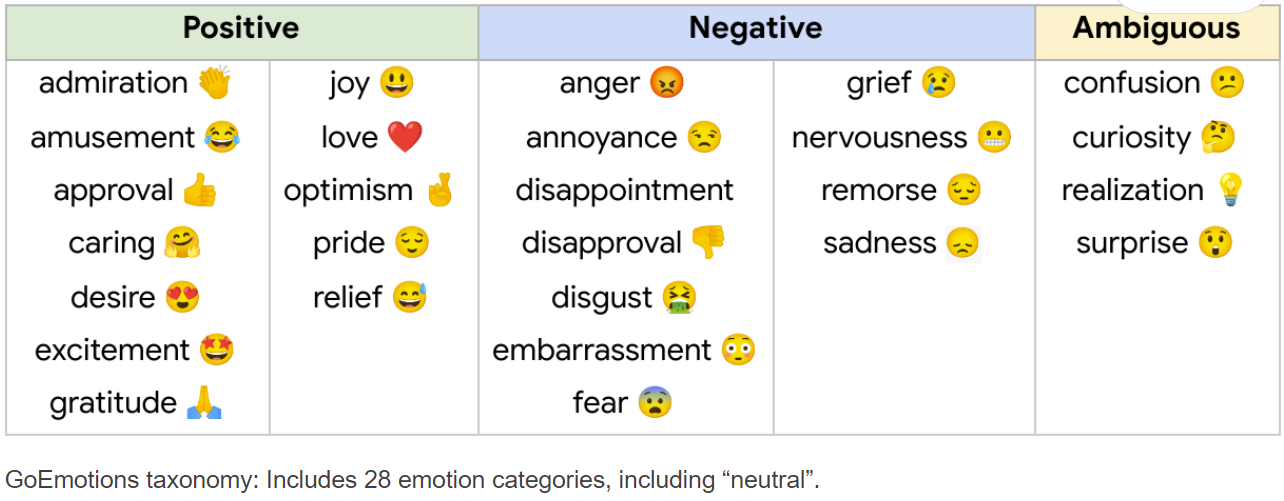Emotion Label	Numerical Representation


Since 27 emotions can get tough to visualize, I decided to select one emotion from each bucket so that they would hopefully cluster well. SO for a balanced representation of different emotional experiences, I selected

1. Joy: for positive feelings and happiness
2. Anger: strong hostility - negative feeling
3. Surprise: kind of neutral

From each of the selected labels, I randomnly chose 50 data points



In [ ]:
selected_labels = [0, 2, 26]  # Corresponding to Positive, Negative, Neutral

# Creating a subset with 20 data points for each selected label for a balanced small subset
subset = pd.DataFrame()
for label in selected_labels:
    subset = pd.concat([subset, df[df['labels'] == label].sample(n=50, random_state=42)])

subset = subset.sample(frac=1, random_state=42).reset_index(drop=True)
subset['labels'] = subset['labels'].apply(lambda x: 1 if x == 26 else x)
print(subset.head())

                                                text  labels
0  Crowder is terrible... How do you lose that gu...       2
1  haha I didnt remember that Rampage was there l...       0
2  Wow, the interview with her mom really made th...       1
3            I could crush him like a bug right now.       2
4  I can't even imagine the stupid tattoo I'd hav...       2


In [ ]:
df = subset

In [ ]:
# to verfiy whether we have representation from all emotions
df['labels'].unique()

array([2, 0, 1])

In [ ]:
def get_sentiment_embeddings(texts):
    # Use a sentiment-specific fine-tuned model
    model_sentiment = SentenceTransformer('cardiffnlp/twitter-roberta-base-sentiment')
    sentiment_embeddings = model_sentiment.encode(texts)

    # Use another sentiment-specific model
    model_sentiment_2 = SentenceTransformer('nlptown/bert-base-multilingual-uncased-sentiment')
    sentiment_embeddings_2 = model_sentiment_2.encode(texts)

    # General-purpose embedding model
    model_general = SentenceTransformer('all-mpnet-base-v2')  # # had also tried sentence-t5-xl and all-MiniLM-L12-v2
    general_embeddings = model_general.encode(texts)

    return sentiment_embeddings, sentiment_embeddings_2, general_embeddings


In [ ]:
# generate and add embeddings to the dataframe

embeddings_1, embeddings_2, embeddings_3 = get_sentiment_embeddings(df['text'].tolist())
df['embeddings_roberta_sentiment'] = list(embeddings_1)
df['embeddings_bert_base'] = list(embeddings_2)
df['embeddings_all-mpnet-base-v2'] = list(embeddings_3)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
df.head()

,text,labels,embeddings_roberta_sentiment,embeddings_bert_base,embeddings_all-mpnet-base-v2
0,Crowder is terrible... How do you lose that gu...,2,"[-0.14912577, -0.6476539, -0.16214855, -1.2037...","[-0.29670852, 0.13504423, -0.34695342, -0.4517...","[-0.03639905, -0.015499487, 0.021517541, 0.004..."
1,haha I didnt remember that Rampage was there l...,0,"[0.48974958, 0.86385757, -0.28753963, -0.70915...","[-0.50716954, -0.018916083, -0.32086304, -0.51...","[0.002483102, -0.03323909, 0.022197815, 0.0172..."
2,"Wow, the interview with her mom really made th...",1,"[0.63324696, 0.85956985, -0.24153951, -1.12606...","[-0.13965377, -0.52704674, 0.09596076, -0.3551...","[-0.060373224, 0.09071158, -0.005074872, 0.000..."
3,I could crush him like a bug right now.,2,"[0.35005367, -0.2315135, -0.2616297, -0.498109...","[-0.19707954, 0.005443558, -0.123734556, -0.73...","[-0.031383384, 0.02291938, 0.035195787, 0.0035..."
4,I can't even imagine the stupid tattoo I'd hav...,2,"[0.09596722, -0.22978319, 0.045623865, -0.8221...","[-0.3547066, -0.15251158, 0.017815366, -0.2920...","[0.04429079, -0.005741774, 0.0027428134, -0.00..."


In [ ]:
 # Dimensionality reductions techniques functions
 # Tried hyperparameter tuning but didnt seem to affect the results much

def apply_tsne(embeddings, perplexity=30, learning_rate=200, n_iter=1000):
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=learning_rate, n_iter=n_iter, random_state=42)
    return tsne.fit_transform(embeddings)

def apply_pca(embeddings, n_components=2):
    pca = PCA(n_components=n_components)
    return pca.fit_transform(embeddings)

def apply_umap(embeddings, n_neighbors=15, min_dist=0.1, metric='euclidean'):
    reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=42)
    return reducer.fit_transform(embeddings)

In [ ]:
models = ['embeddings_roberta_sentiment', 'embeddings_bert_base', 'embeddings_all-mpnet-base-v2']

# PCA

 a linear technique that reduces dimensions by maximizing variance. It finds the directions (principal components) that capture the most variance in the data.

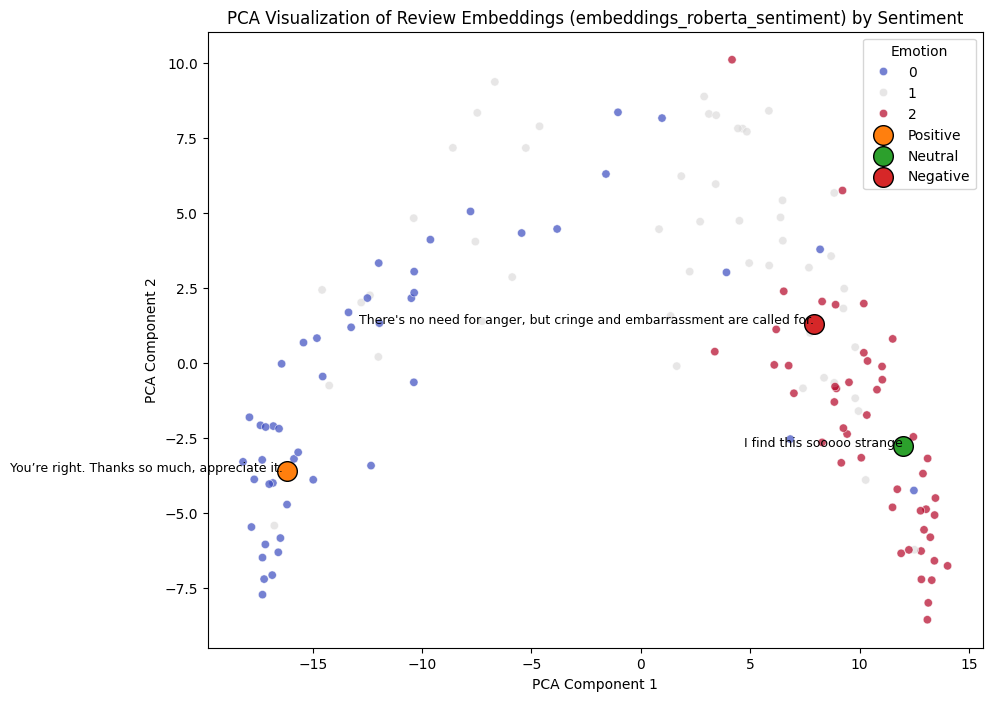

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129416 (\N{SHARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


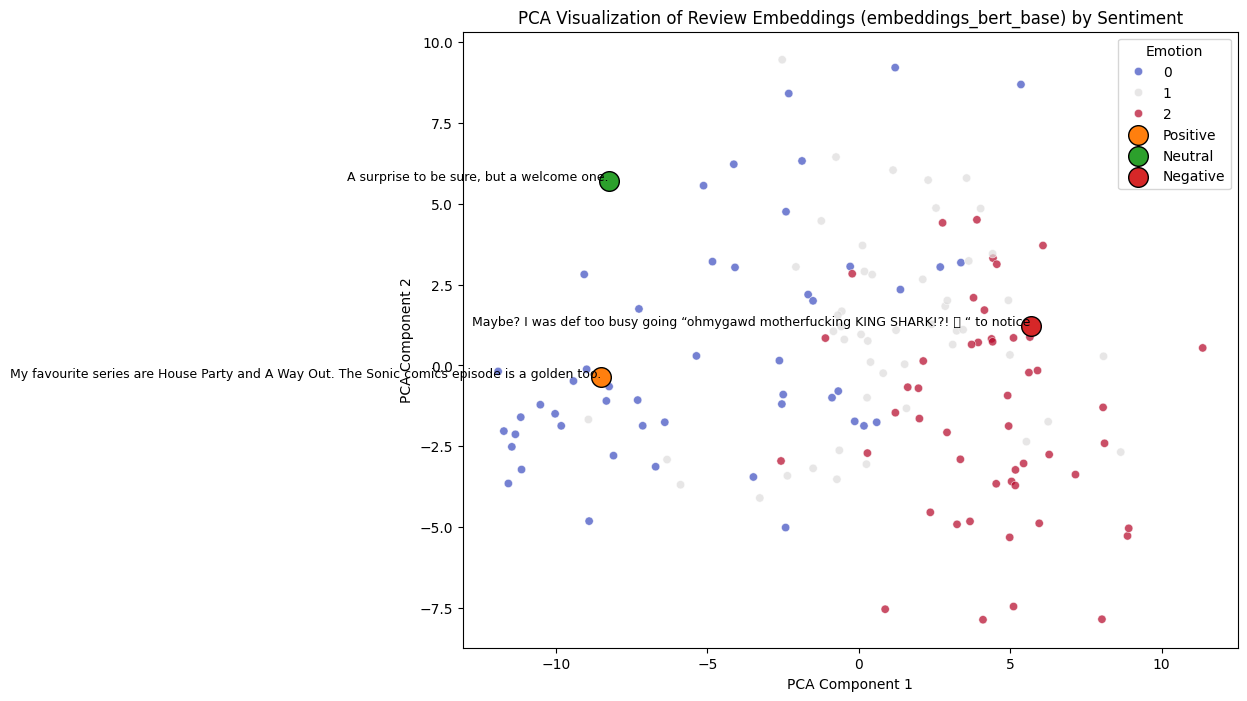

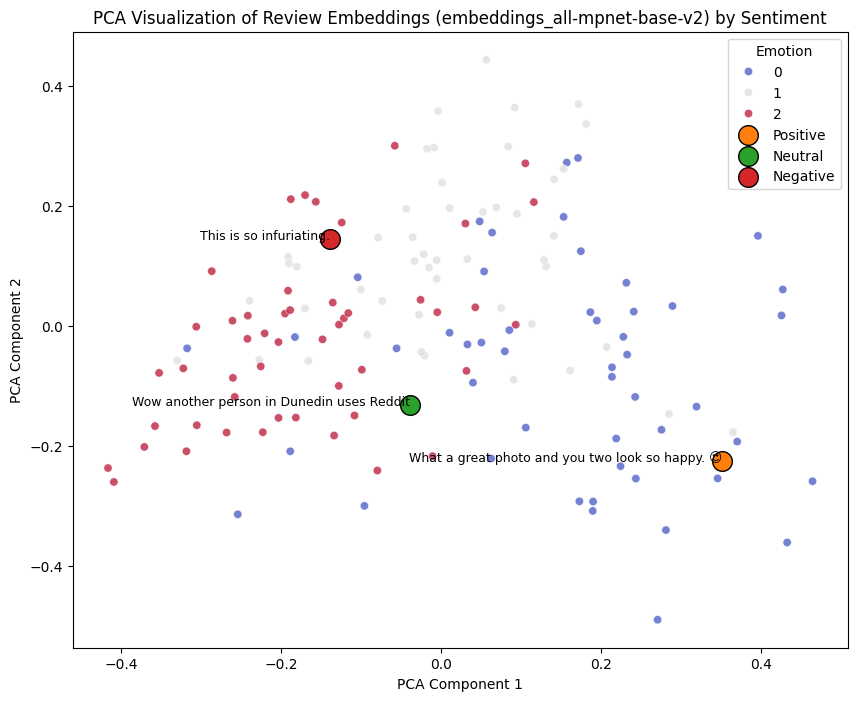

In [ ]:
# Create a mapping from label index to emotion name for better readability
emotion_mapping = {
    0: 'Positive',
    1: 'Neutral',
    2: 'Negative',
}

# Apply and visualize PCA
for model in models:
    embeddings = np.vstack(df[model].values)  # Stack the embeddings
    pca_results = apply_pca(embeddings)
    df[f'pca_x_{model}'] = pca_results[:, 0]
    df[f'pca_y_{model}'] = pca_results[:, 1]

    # Visualize
    plt.figure(figsize=(10, 8))

    # Scatter plot for all points
    scatter = sns.scatterplot(data=df, x=f'pca_x_{model}', y=f'pca_y_{model}', hue='labels',
                              palette='coolwarm', alpha=0.7)

    # Highlight a random dot from each emotion
    for label in emotion_mapping.keys():
        sample_point = df[df['labels'] == label].sample(1)
        plt.scatter(sample_point[f'pca_x_{model}'], sample_point[f'pca_y_{model}'],
                    s=200, edgecolor='black', label=emotion_mapping[label], marker='o')  # Highlighted points
        plt.text(sample_point[f'pca_x_{model}'].values[0],
                 sample_point[f'pca_y_{model}'].values[0],
                 sample_point['text'].values[0], fontsize=9, ha='right')  # Display text

    plt.title(f"PCA Visualization of Review Embeddings ({model}) by Sentiment")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend(title='Emotion')
    plt.show()


#### CardiffNLP Twitter RoBERTa Base Sentiment
The model shows relatively distinct clusters for different sentiments, indicating it effectively captures sentiment variations. Positive, neutral, and negative sentiments are somewhat separated. Whats noteworthy is that none of the positive negative sentimentsseem to be strongly clustering together which is good. Neutral at times is all over the place. This model seems well-suited for distinguishing between sentiment categories, which aligns with its design for Twitter sentiment analysis.

#### NLPTown BERT Multilingual Sentiment
There is a moderate separation of sentiment clusters. However, there is some overlap, suggesting it may not differentiate as sharply as the roberta model. While capable of handling multilingual data, its performance on emotion differentiation appears less distinct compared to the Twitter-specific model.

#### all-mpnet-base-v2
This is a general-purpose model which captures "semantic similarities" and not "sentiments" or "emotions" particularly so shows less distinct clustering compared to the sentiment-specific models. The overlap among different sentiments is more pronounced.
Interpretation: As a baseline model not specifically tuned for sentiment analysis, it serves as a useful comparison but does not excel in differentiating emotional content.

Overall, Roberta model is most efficient.

## Extra Analysis!
Applied KMeans clustering to analyze how well the model distinguishes between different emotional sentiments by manually checking the texts in a cluster. Thought it just a good way to identify any potential ambiguities in classification, and gain insights into how different emotional expressions are represented in the embedding space.

In [ ]:
from sklearn.cluster import KMeans

n_clusters = 3

# For roberta model
model = 'embeddings_roberta_sentiment'
embeddings = np.vstack(df[model].values)

# Apply PCA
pca_results = apply_pca(embeddings)
df[f'pca_x_{model}'] = pca_results[:, 0]
df[f'pca_y_{model}'] = pca_results[:, 1]

# Fit KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(pca_results)

df[f'cluster_{model}'] = cluster_labels

# Print samples for each cluster
print(f"\nRepresentative Samples for {model}:\n")
for cluster in range(n_clusters):
    print(f"Cluster {cluster}:\n")
    sample_points = df[df[f'cluster_{model}'] == cluster].sample(10, random_state=42)  # Get 5 random samples from each cluster
    print(sample_points[['text', 'labels']])
    print("\n" + "="*50 + "\n")



Representative Samples for embeddings_roberta_sentiment:

Cluster 0:

                                                  text  labels
81   This is truly the most captivating trilogy I’v...       0
121  Yesssss!!! [NAME] would be awesome!!! I also a...       0
78                   That’s a great idea! Thank you :)       0
132               That's the best catch I've ever seen       0
72           A surprise to be sure, but a welcome one.       1
105  I’m here for a final set match TB like this ma...       0
37   Omg this is awesome. What a witch, I’m so glad...       0
56   Honestly, I love hearing about stories like th...       0
12                                           Clever!!!       0
73     Wow 😮 you really convinced me... like gtfo here       1


Cluster 1:

                                                  text  labels
125                                     Damn straight.       2
145  A sharp stick? I think you need a rifle to kil...       2
0    Crowder is terrible... How d

Cluster 0 predominantly features texts that express positive and neutral sentiments, with phrases like "this is truly the most captivating trilogy" and "A surprise to be sure, but a welcome one." Most samples are labeled as positive (0) or neutral (1), indicating the model effectively captures uplifting emotions.

Cluster 1 is characterized by negative sentiments, evident in statements such as "Crowder is terrible" Here, the majority of texts are classified as negative (2), although some neutral comments suggest a slight overlap, highlighting potential ambiguities in emotional expression.

Cluster 2 displays a mix of emotions, containing both neutral and ironic texts like "Oh, the irony" and "Interesting... is it a felony in certain jurisdictions?" This cluster exhibits a more nuanced emotional landscape, with a blend of positive (0), neutral (1), and negative (2) labels, suggesting that the model may struggle to categorize sentiments that are less clear-cut like the one text marked (2) is sort of ambiguous to be labeled angry.

# T-SNE
designed to visualize high-dimensional data by focusing on preserving local relationships between data points. Although, not very interpretable since distances between clusters may not correspond to actual distances in the original data.

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


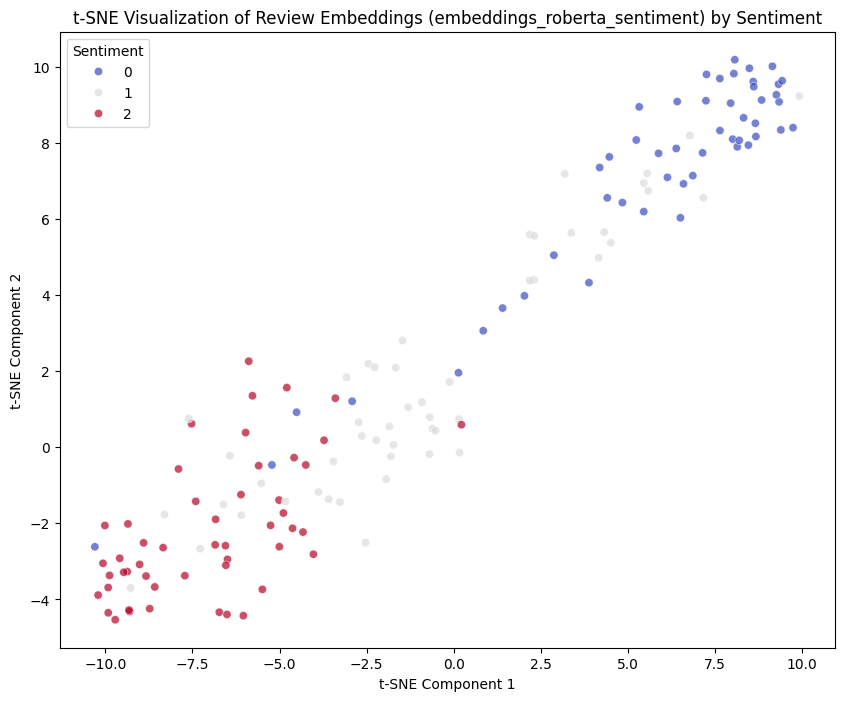

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


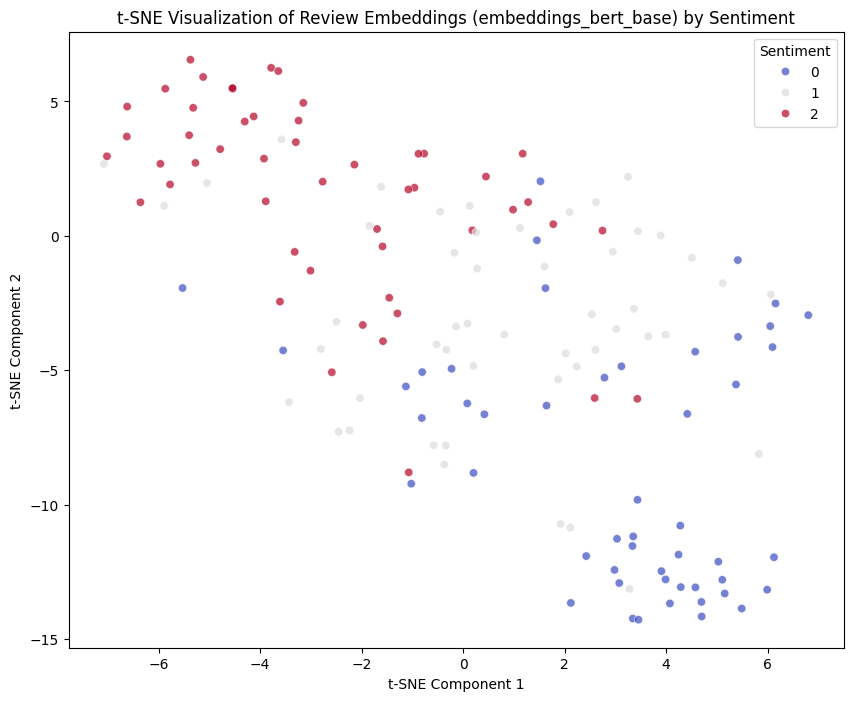

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


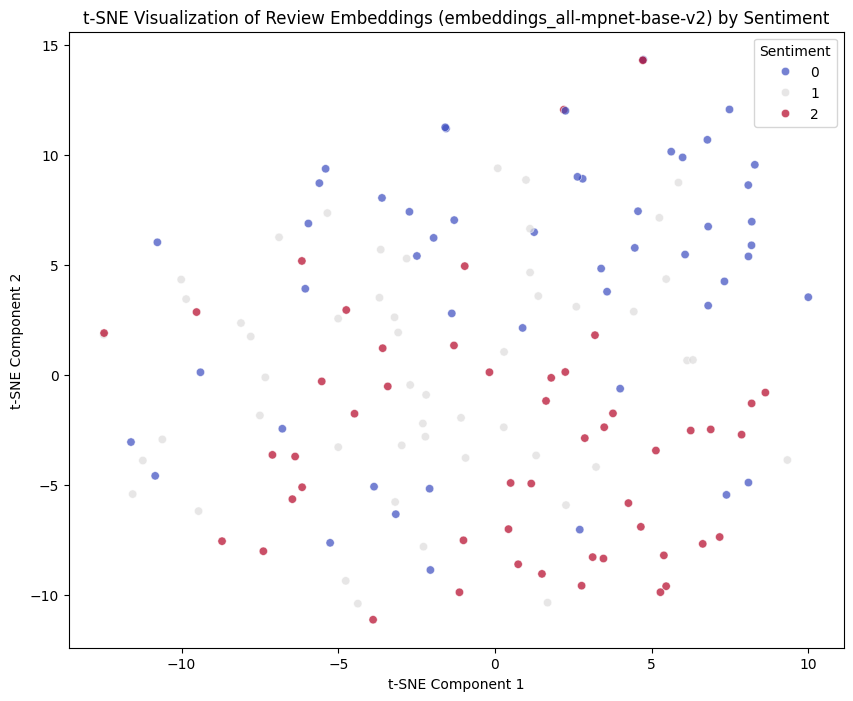

In [ ]:
# Apply and visualize T-SNE
for model in models:
    embeddings = np.vstack(df[model].values)  # Stack the embeddings
    tsne_results = apply_tsne(embeddings)
    df[f'tsne_x_{model}'] = tsne_results[:, 0]
    df[f'tsne_y_{model}'] = tsne_results[:, 1]

    # Visualize
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x=f'tsne_x_{model}', y=f'tsne_y_{model}', hue='labels', palette='coolwarm', alpha=0.7)
    plt.title(f"t-SNE Visualization of Review Embeddings ({model}) by Sentiment")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(title='Sentiment')
    plt.show()

#### CardiffNLP Twitter RoBERTa Base Sentiment
Sentiment 0 is well-separated, but there is confusion between sentiments 1 and 2.

#### NLPTown BERT Multilingual Sentiment
Shows some separation, but there is overlap among all sentiments. The model's multilingual focus might affect its clarity in sentiment differentiation.

#### all-mpnet-base-v2
Significant overlap among sentiments. As a general-purpose model, it lacks specialization for sentiment analysis which is more apparent for T-SNE as compared to PCA

# U-MAP

UMAP is a non-linear technique focused on both local and global structure preservation.


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


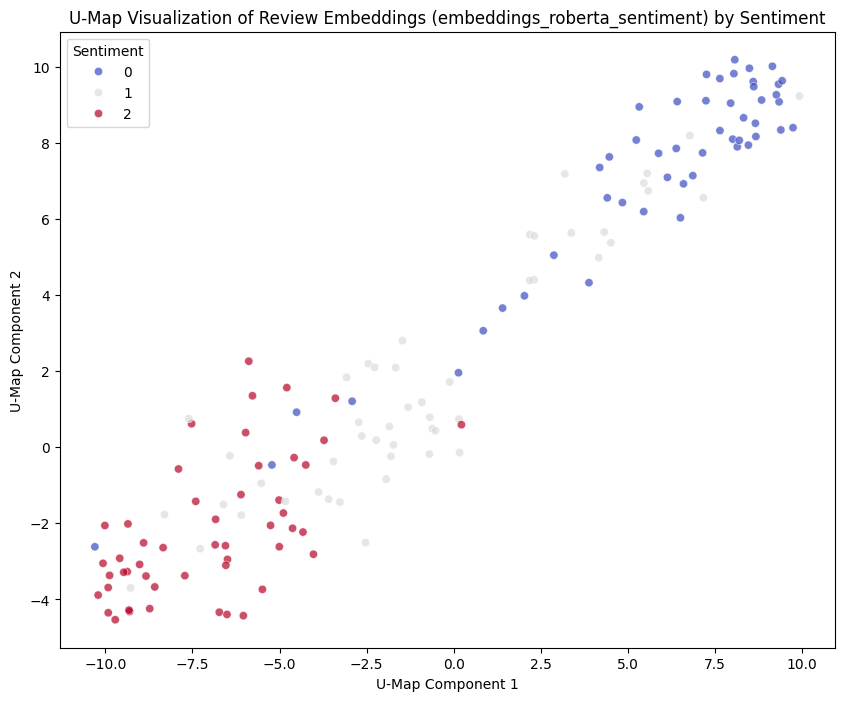

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


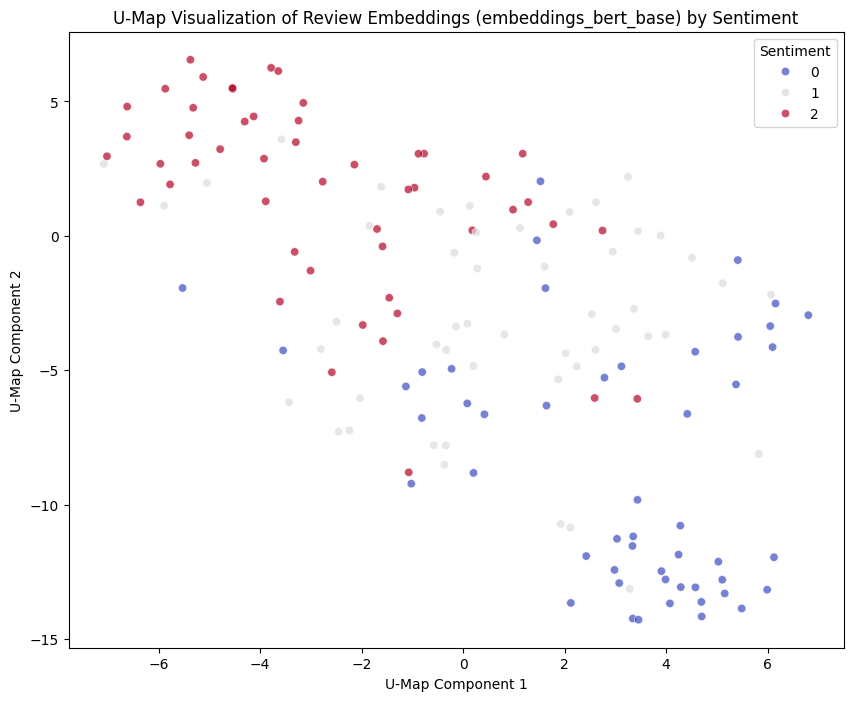

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


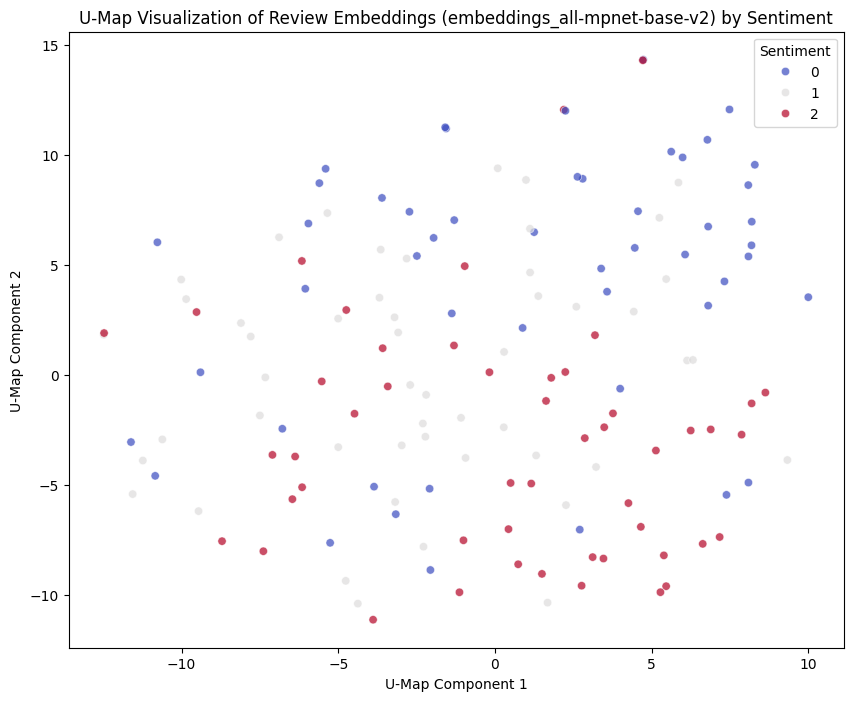

In [ ]:
# Apply and visualize U-Map
for model in models:
    embeddings = np.vstack(df[model].values)  # Stack the embeddings
    umap_results = apply_tsne(embeddings)
    df[f'umap_x_{model}'] = umap_results[:, 0]
    df[f'umap_y_{model}'] = umap_results[:, 1]

    # Visualize
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x=f'umap_x_{model}', y=f'umap_y_{model}', hue='labels', palette='coolwarm', alpha=0.7)
    plt.title(f"U-Map Visualization of Review Embeddings ({model}) by Sentiment")
    plt.xlabel("U-Map Component 1")
    plt.ylabel("U-Map Component 2")
    plt.legend(title='Sentiment')
    plt.show()

These results are pretty similar to T-SNE where Roberta seems to be performing decently but still clusters 1 and 2 all together whereas, bert performs decently whereas the general purpose model embeddings visualizations are all over the place.

# Overall Comparison

- For T-SNE; Sentiment 0 is clearly separated, but there is some confusion between sentiments 1 and 2.
- PCA provides a more linear separation of sentiments, showing clearer distinctions between categories. PCA focuses on variance along principal components, offering a broader view of sentiment separation.
-  Similar to t-SNE, UMAP shows distinct clusters for sentiment 0, with some overlap between sentiments 1 and 2.


The CardiffNLP Twitter RoBERTa Base Sentiment model performs well across all visualizations, particularly in distinguishing sentiment 0. The RoBERTa model is fine-tuned for sentiment analysis, making it adept at capturing sentiment nuances.

PCA provides the clearest overall separation.